# 09 — Two-Dimensional Fourier Transforms and Images

## Learning goals

- Interpret image Fourier transforms as spatial-frequency spectra.
- See low-pass, high-pass, and band-pass filtering.
- Understand why phase matters strongly for image structure.
- Use Fourier coefficients for simple image compression.

## Mental model

An image is a stack of transparent corrugated sheets. Each sheet has a stripe spacing, orientation, amplitude, and phase. The 2D Fourier transform lists those sheets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Create a synthetic image with blobs and stripes

Low spatial frequencies create broad smooth shapes. High spatial frequencies create fine detail and edges.

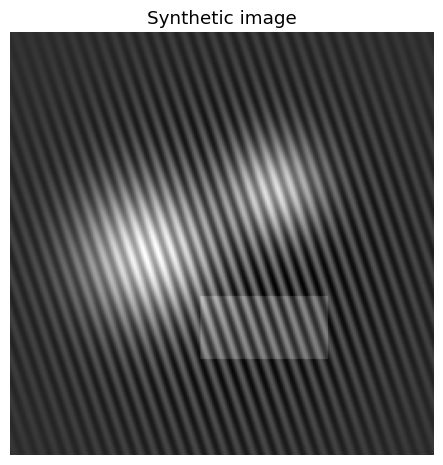

In [2]:
N = 256
y, x = np.mgrid[-1:1:complex(N), -1:1:complex(N)]

blob1 = np.exp(-((x+0.35)**2 + (y+0.05)**2)/(2*0.22**2))
blob2 = 0.8*np.exp(-((x-0.25)**2 + (y-0.25)**2)/(2*0.16**2))
mask = np.exp(-((x-0.05)**2 + (y+0.1)**2)/(2*0.65**2))
stripes = 0.35*np.sin(2*np.pi*(15*x + 5*y)) * mask
edge = 0.25*(x > -0.1)*(x < 0.5)*(y > -0.55)*(y < -0.25)
image = blob1 + blob2 + stripes + edge
image = (image - image.min())/(image.max()-image.min())

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(image, cmap="gray", origin="lower")
ax.set_title("Synthetic image")
ax.axis("off")
plt.show()

## 2D FFT: amplitude and phase spectra

The center of the shifted spectrum is zero spatial frequency. Distance from the center corresponds to spatial frequency. Angle corresponds to orientation.

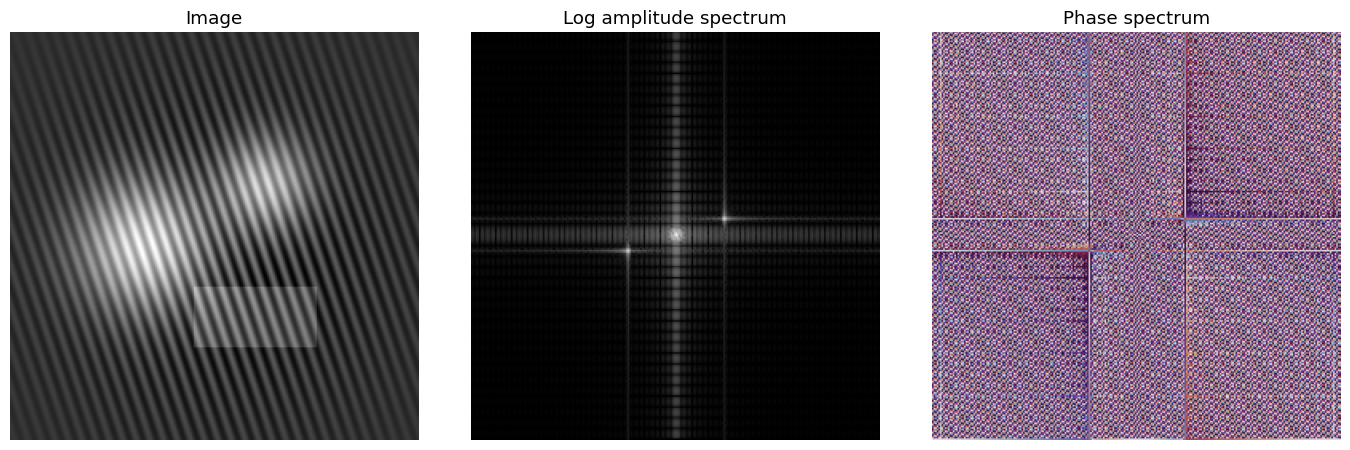

In [3]:
F = np.fft.fft2(image)
F_shift = np.fft.fftshift(F)
amplitude = np.log1p(np.abs(F_shift))
phase = np.angle(F_shift)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.5))
axs[0].imshow(image, cmap="gray", origin="lower")
axs[0].set_title("Image")
axs[1].imshow(amplitude, cmap="gray", origin="lower")
axs[1].set_title("Log amplitude spectrum")
axs[2].imshow(phase, cmap="twilight", origin="lower")
axs[2].set_title("Phase spectrum")
for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Low-pass, high-pass, and band-pass filtering

A circular mask in the Fourier domain selects spatial-frequency ranges.

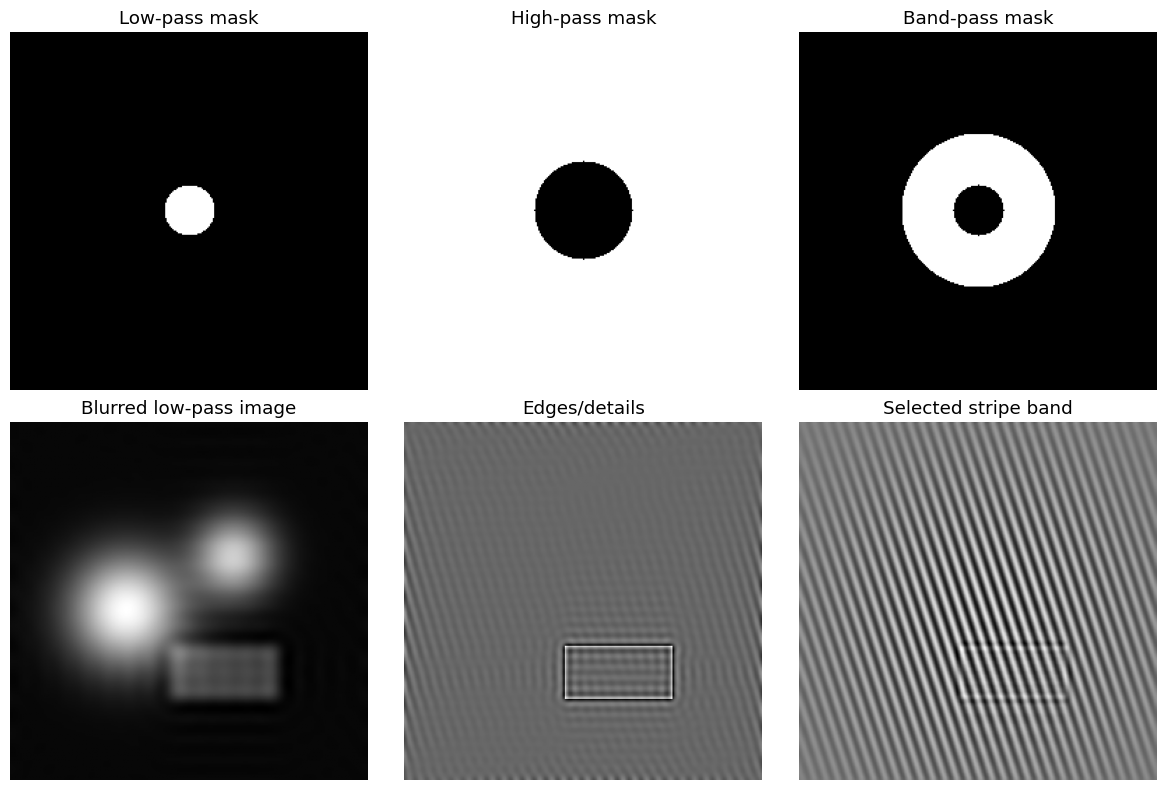

In [4]:
cy = cx = N//2
Y, Xgrid = np.ogrid[:N, :N]
r = np.sqrt((Y-cy)**2 + (Xgrid-cx)**2)

low_mask = r < 18
high_mask = r > 35
band_mask = (r > 18) & (r < 55)

def apply_mask(F_shift, mask):
    return np.fft.ifft2(np.fft.ifftshift(F_shift*mask)).real

low_img = apply_mask(F_shift, low_mask)
high_img = apply_mask(F_shift, high_mask)
band_img = apply_mask(F_shift, band_mask)

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for ax, m, title in zip(axs[0], [low_mask, high_mask, band_mask], ["Low-pass mask", "High-pass mask", "Band-pass mask"]):
    ax.imshow(m, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")
for ax, img, title in zip(axs[1], [low_img, high_img, band_img], ["Blurred low-pass image", "Edges/details", "Selected stripe band"]):
    ax.imshow(img, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Phase matters

The amplitude spectrum says which spatial frequencies are present. The phase spectrum says where they line up. For images, phase carries much of the recognizable structure.

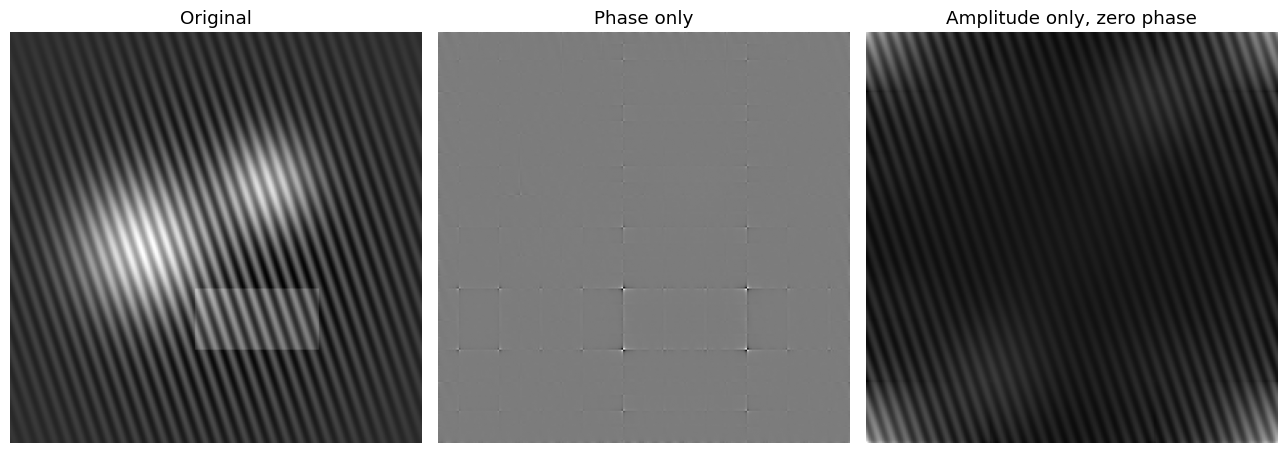

In [5]:
amp = np.abs(F)
ph = np.angle(F)

# Reconstruct with original phase and flattened amplitude.
phase_only = np.fft.ifft2(np.exp(1j*ph)).real
# Reconstruct with original amplitude and zero phase.
amplitude_only = np.fft.ifft2(amp).real

fig, axs = plt.subplots(1, 3, figsize=(13, 4.5))
axs[0].imshow(image, cmap="gray", origin="lower")
axs[0].set_title("Original")
axs[1].imshow(phase_only, cmap="gray", origin="lower")
axs[1].set_title("Phase only")
axs[2].imshow(amplitude_only, cmap="gray", origin="lower")
axs[2].set_title("Amplitude only, zero phase")
for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Compression by keeping large coefficients

Keeping only a small fraction of Fourier coefficients can preserve the broad appearance of an image. The price is loss of detail or ringing artifacts.

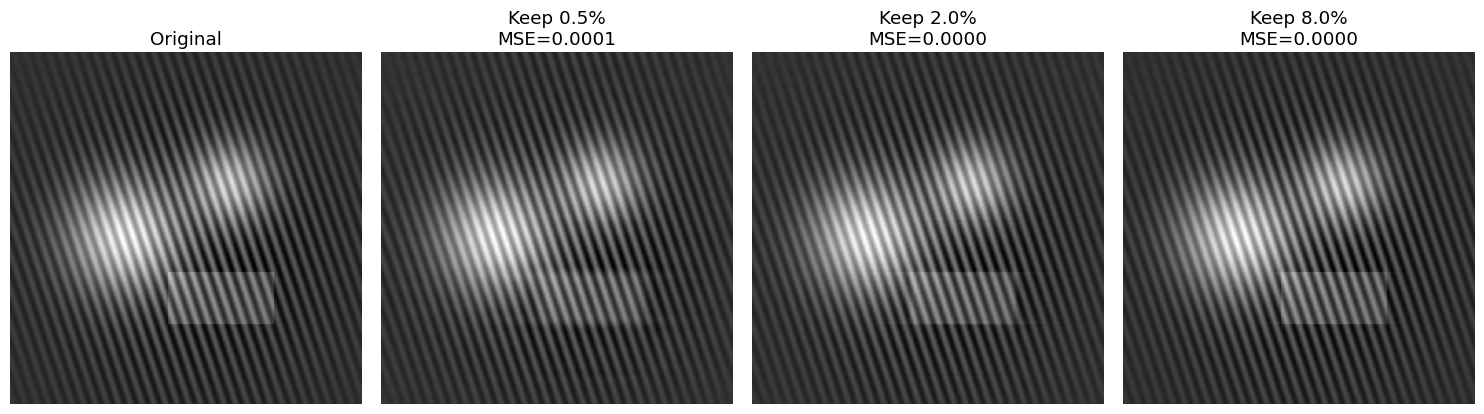

In [6]:
fractions = [0.005, 0.02, 0.08]
flat_amp = np.abs(F).ravel()

fig, axs = plt.subplots(1, len(fractions)+1, figsize=(15, 4))
axs[0].imshow(image, cmap="gray", origin="lower")
axs[0].set_title("Original")
axs[0].axis("off")

for ax, frac in zip(axs[1:], fractions):
    threshold = np.quantile(flat_amp, 1-frac)
    F_comp = F * (np.abs(F) >= threshold)
    recon = np.fft.ifft2(F_comp).real
    mse = np.mean((image-recon)**2)
    ax.imshow(recon, cmap="gray", origin="lower")
    ax.set_title(f"Keep {100*frac:.1f}%\nMSE={mse:.4f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Orientation example

A single oriented grating creates two bright points in the Fourier spectrum: one for each opposite direction of the same spatial frequency.

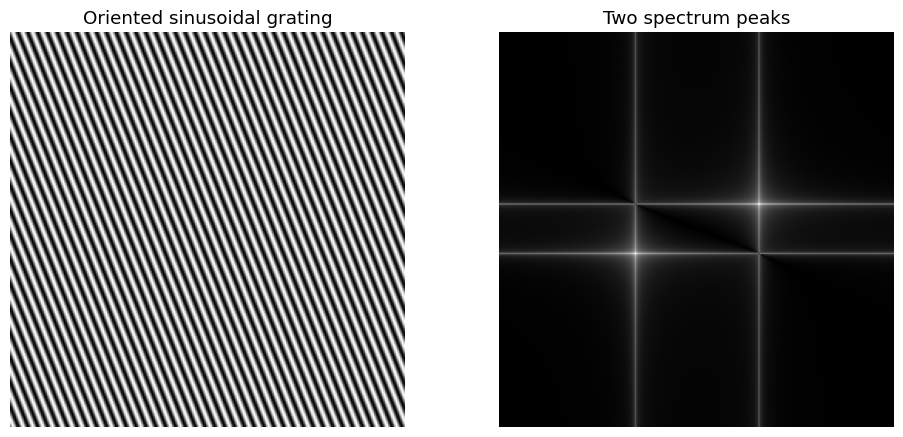

In [7]:
grating = np.sin(2*np.pi*(20*x + 8*y))
G = np.fft.fftshift(np.fft.fft2(grating))

fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))
axs[0].imshow(grating, cmap="gray", origin="lower")
axs[0].set_title("Oriented sinusoidal grating")
axs[0].axis("off")
axs[1].imshow(np.log1p(np.abs(G)), cmap="gray", origin="lower")
axs[1].set_title("Two spectrum peaks")
axs[1].axis("off")
plt.tight_layout()
plt.show()

## Checkpoint

1. Increase the stripe frequency from 15 to 30. Where do the spectrum peaks move?
2. Keep only low frequencies. Why does the image blur?
3. Why does phase-only reconstruction still look structured?